# RLBench Simulation Scene Visualization

This notebook allows you to open a simulation scene based on the configuration layout in `../conf/eval.yaml`, visualize the camera inputs (RGB and Depth) before stepping the environment, and manually adjust camera positions.

In [4]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import hydra
from hydra import compose, initialize
from omegaconf import OmegaConf, DictConfig, ListConfig

# Add the project root to sys.path
project_root = os.path.abspath(os.path.join(os.getcwd(), "../../"))
if project_root not in sys.path:
    sys.path.append(project_root)

# Import project modules
from rlbench.backend.utils import task_file_to_task_class
from rlbench import ObservationConfig, ActionMode
from rlbench.action_modes.action_mode import MoveArmThenGripper, BimanualMoveArmThenGripper, BimanualJointPositionActionMode
from rlbench.action_modes.arm_action_modes import EndEffectorPoseViaPlanning, BimanualEndEffectorPoseViaPlanning, BimanualJointPosition, JointPosition
from rlbench.action_modes.gripper_action_modes import Discrete, BimanualDiscrete, BimanualGripperJointPosition
from helpers import observation_utils
from helpers.custom_rlbench_env import CustomRLBenchEnv
from rlbench.backend import task as rlbench_task

%matplotlib inline

## 1. Load Configuration

We use Hydra to load the `eval.yaml` configuration just like `eval.py` does.

In [5]:
config_path = '/home/zsh/dcoda/11/logs/2026_03_04_21_01_coordinated_lift_ball_200_demos_43/ACT_BC_LANG/seed43/config.yaml'
if os.path.exists(config_path):
    with open(config_path, "r") as f:
        cfg = OmegaConf.load(f)
else:
    print('error')

# Inspect loaded tasks
print(f"Tasks loaded from config: {cfg.rlbench.tasks}")
print(f"Cameras loaded from config: {cfg.rlbench.cameras}")

Tasks loaded from config: ['coordinated_lift_ball']
Cameras loaded from config: ['wrist_right', 'wrist_left']


## 2. Environment Setup

We setup the `CustomRLBenchEnv` using the loaded configuration. You can change `TASK_NAME` below to select a specific task from the list.

In [6]:
# Select a task
TASK_NAME = cfg.rlbench.tasks[0]  # Change index to select different task if multiple are present
print(f"Selected Task: {TASK_NAME}")

# Determine if bimanual
is_bimanual = cfg.method.robot_name == "bimanual"
print(f"Robot Name: {cfg.method.robot_name}, Bimanual: {is_bimanual}")

# Get Task Class
task_class = task_file_to_task_class(TASK_NAME, is_bimanual)
print(cfg.rlbench)
# Setup Action Mode
# Depending on your config, you might need to adjust these imports or evals
try:
    gripper_mode = eval(s)()
    arm_action_mode = eval(cfg.rlbench.arm_action_mode)()
except NameError:
    # Fallback if config strings don't match imported names directly
    print("Using default action mode setup as fallback")
    gripper_mode = Discrete()
    arm_action_mode = EndEffectorPoseViaPlanning()
    action_mode = MoveArmThenGripper(arm_action_mode, gripper_mode)

# Setup Observation Config
cam_resolution = cfg.rlbench.camera_resolution
if isinstance(cam_resolution, ListConfig):
    cam_resolution = list(cam_resolution)

obs_config = observation_utils.create_obs_config(
    cfg.rlbench.cameras,
    cam_resolution,
    cfg.method.name,
    cfg.method.robot_name
)

# Force enable depth for all cameras for visualization purposes
# create_obs_config might only enable RGB/PointCloud by default. Let's fix that.
for cam_name, cam_config in obs_config.camera_configs.items():
    cam_config.depth = True
    cam_config.rgb = True
    # render_mode must be proper

print("Observation Config created with RGB and Depth enabled.")

Selected Task: coordinated_lift_ball
Robot Name: bimanual, Bimanual: True
{'task_name': '2026_03_04_21_01_coordinated_lift_ball_200_demos_43', 'tasks': ['coordinated_lift_ball'], 'demos': 200, 'demo_path': '/home/zsh/dcoda/data/rlbench_data/train/coordinated_lift_ball_200_demos_128x128', 'episode_length': 400, 'cameras': ['wrist_right', 'wrist_left'], 'camera_resolution': [128, 128], 'scene_bounds': [-0.3, -0.5, 0.6, 0.7, 0.5, 1.6], 'include_lang_goal_in_obs': True}
Using default action mode setup as fallback
Observation Config created with RGB and Depth enabled.


In [7]:
# Instantiate the Environment
# We force headless=True for stability in notebooks unless you have X server setup properly
HEADLESS = True 

# IMPORTANT: Set system environment variable for Display
# You must have Xvfb running on this port (e.g., in terminal: Xvfb :99 -screen 0 1024x768x24 &)
os.environ["DISPLAY"] = ":99"

env = CustomRLBenchEnv(
    task_class=task_class,
    observation_config=obs_config,
    action_mode=action_mode,
    dataset_root=cfg.rlbench.demo_path,
    episode_length=cfg.rlbench.episode_length,
    headless=HEADLESS,
    include_lang_goal_in_obs=cfg.rlbench.include_lang_goal_in_obs,
)

env.launch()
print("Environment launched.")

Environment launched.


## 3. Visualize Initial State

Reset the environment to get the initial observation. This corresponds to the state before any step is taken.

Resetting environment to get initial observation...
Environment reset complete.
Visualizing and saving cameras: ['wrist_right', 'wrist_left']
None
  Depth Stats: Min=0.0068, Max=0.1742
None
  Depth Stats: Min=0.0068, Max=0.1741


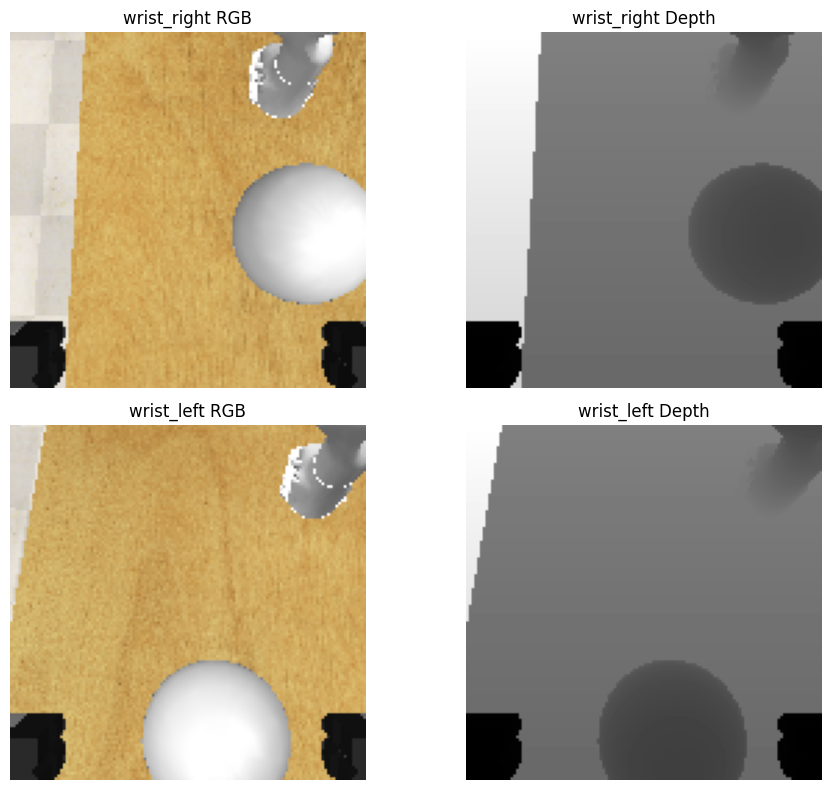

Images and depth maps saved to /home/zsh/dcoda/D-Aug/change_view_demo/captured_images


In [12]:
def visualize_observation(obs_dict, cameras, save_dir="captured_images"):
    """
    Visualizes RGB and Depth for each camera in the observation dictionary.
    Also saves RGB images as .png and Depth maps as .npy files.
    """
    if not os.path.exists(save_dir):
        os.makedirs(save_dir)

    num_cams = len(cameras)
    if num_cams == 0:
        print("No cameras found in config.")
        return

    fig, axes = plt.subplots(num_cams, 2, figsize=(10, 4 * num_cams))
    if num_cams == 1:
        axes = np.expand_dims(axes, 0)

    # Helper to find camera object in current env
    def get_cam_obj(name):
        if 'env' not in globals(): return None
        scene = env._rlbench_env._scene
        if name == 'front': return scene._cam_front
        if name == 'wrist': return scene._cam_wrist
        if name in ['left_shoulder', 'over_shoulder_left']: return scene._cam_over_shoulder_left
        if name in ['right_shoulder', 'over_shoulder_right']: return scene._cam_over_shoulder_right
        if name == 'overhead': return scene._cam_overhead
        if name == 'wrist_left': return getattr(scene, '_cam_wrist_left', None)
        if name == 'wrist_right': return getattr(scene, '_cam_wrist_right', None)
        return None

    for i, cam_name in enumerate(cameras):
        # Print Depth Info
        cam_obj = get_cam_obj(cam_name)
        print(cam_obj)
        if cam_obj:
            near = cam_obj.get_near_clipping_plane()
            far = cam_obj.get_far_clipping_plane()
            print(f"Camera '{cam_name}': Near={near:.4f}, Far={far:.4f}")

        # Construct keys based on camera name 
        # Note: key naming convention depends on helpers/observation_utils.py
        rgb_key = f"{cam_name}_rgb"
        depth_key = f"{cam_name}_depth"
        
        # Handle potential key discrepancies (e.g. 'left_shoulder' vs 'over_shoulder_left')
        # Check if keys exist, if not try to find close match
        if rgb_key not in obs_dict:
             # try alternative naming if needed (e.g. standard rlbench keys)
             # but creating proper mapping is better. 
             # Printing available keys for debugging
             print(f"Warning: Key {rgb_key} not found. Available keys: {list(obs_dict.keys())}")
             continue

        rgb = obs_dict[rgb_key]
        depth = obs_dict.get(depth_key, None)

        # Handle channel dimensions (might be channels_first or channels_last)
        # standard rlbench obs are usually [H, W, C] but extract_obs might transpose
        if rgb.shape[0] == 3:
            rgb = np.transpose(rgb, (1, 2, 0))
        
        # Save RGB
        plt.imsave(os.path.join(save_dir, f"{cam_name}_rgb.png"), rgb)

        axes[i, 0].imshow(rgb)
        axes[i, 0].set_title(f"{cam_name} RGB")
        axes[i, 0].axis('off')

        if depth is not None:
            if depth.shape[0] == 1:
                depth = np.transpose(depth, (1, 2, 0))
            
            # Save Depth
            print(f"  Depth Stats: Min={depth.min():.4f}, Max={depth.max():.4f}")
            np.save(os.path.join(save_dir, f"{cam_name}_depth.npy"), depth)

            axes[i, 1].imshow(depth.squeeze(), cmap='gray')
            axes[i, 1].set_title(f"{cam_name} Depth")
            axes[i, 1].axis('off')
        else:
            axes[i, 1].text(0.5, 0.5, 'No Depth', ha='center')
            axes[i, 1].axis('off')

    plt.tight_layout()
    plt.show()
    print(f"Images and depth maps saved to {os.path.abspath(save_dir)}")

print("Resetting environment to get initial observation...")
initial_obs = env.reset()
print("Environment reset complete.")

# Extract camera names from config to iterate over
camera_names = cfg.rlbench.cameras
if isinstance(camera_names, ListConfig):
    camera_names = list(camera_names)
    
print(f"Visualizing and saving cameras: {camera_names}")
visualize_observation(initial_obs, camera_names)

### 4. Comparison of the two method

camera local shift: 0.08 -0.07 0.04
camera local rotation (deg): 4.0 -3.0000000000000004 5.0
PKL near/far = 0.009999999776482582 10.0
original cam pose: [ 0.21904092 -0.24385996  1.57334721 -0.70498848  0.70498627  0.05472048
 -0.05469347]
orig depth: 0.06786636 1.7417922 (128, 128)
real move old pos: [ 0.21900393 -0.24385089  1.57331157]
real move new pos: [ 0.28199787 -0.32384934  1.52299247]
real move old quat: [-0.70498884  0.70498914  0.05469813 -0.05467348]
real move new quat: [-0.67287576  0.73829978  0.04413585 -0.01427161]


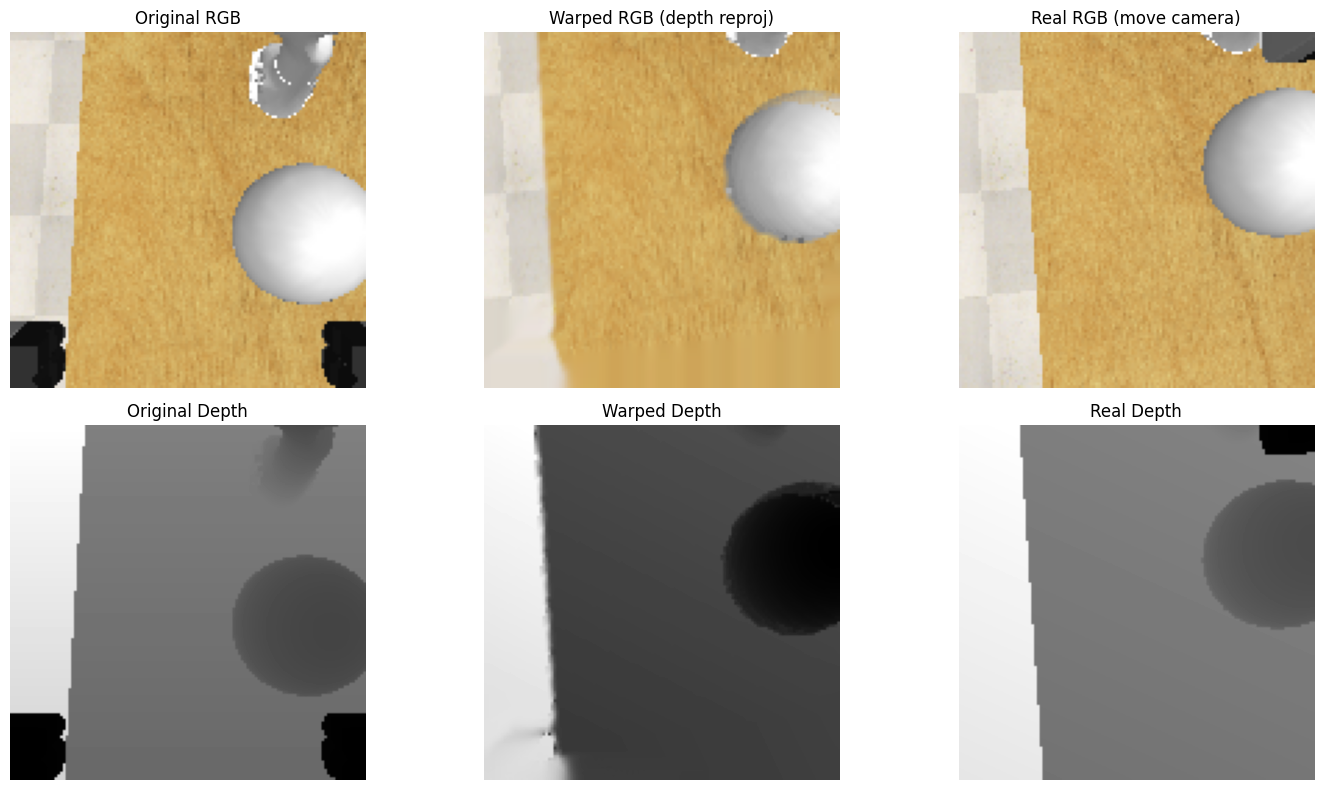

Mean RGB abs diff   = 8.0896
Mean Depth abs diff = 0.783654
Saved to: /home/zsh/dcoda/D-Aug/change_view_demo/changed_view


In [14]:
import os
import copy
import random
import pickle
import numpy as np
import matplotlib.pyplot as plt
import cv2

from PIL import Image
from scipy.spatial.transform import Rotation as R

# =========================================================
# 0. 参数
# =========================================================
pkl_path = "/home/zsh/dcoda/data/rlbench_data/train/coordinated_lift_ball_200_demos_128x128/coordinated_lift_ball/all_variations/episodes/episode88/low_dim_obs.pkl"
save_dir = "./changed_view"
os.makedirs(save_dir, exist_ok=True)

cam_name = "cam_wrist_right"

# 你指定的局部相机运动
delta_X = 0.08
delta_Y = -0.07
delta_Z = 0.04

roll  = np.deg2rad(4)
pitch = np.deg2rad(-3)
yaw   = np.deg2rad(5)

print("camera local shift:", delta_X, delta_Y, delta_Z)
print("camera local rotation (deg):",
      np.rad2deg(roll), np.rad2deg(pitch), np.rad2deg(yaw))

# =========================================================
# 1. 工具函数
# =========================================================
def euler_to_matrix(roll, pitch, yaw):
    Rx = np.array([
        [1, 0, 0],
        [0, np.cos(roll), -np.sin(roll)],
        [0, np.sin(roll),  np.cos(roll)]
    ], dtype=np.float64)

    Ry = np.array([
        [ np.cos(pitch), 0, np.sin(pitch)],
        [0, 1, 0],
        [-np.sin(pitch), 0, np.cos(pitch)]
    ], dtype=np.float64)

    Rz = np.array([
        [np.cos(yaw), -np.sin(yaw), 0],
        [np.sin(yaw),  np.cos(yaw), 0],
        [0, 0, 1]
    ], dtype=np.float64)

    return Rz @ Ry @ Rx  # ZYX

def find_object_by_name(env, name):
    for obj in env._task._scene.pyrep.get_objects_in_tree():
        if obj.get_name() == name:
            return obj
    return None

def move_object_in_local_frame(obj, delta_pos_local, delta_euler_local, degrees=False):
    delta_pos_local = np.asarray(delta_pos_local, dtype=np.float64)
    delta_euler_local = np.asarray(delta_euler_local, dtype=np.float64)

    pose = np.asarray(obj.get_pose(), dtype=np.float64)
    cur_pos_world = pose[:3]
    cur_quat_xyzw = pose[3:]

    cur_rot = R.from_quat(cur_quat_xyzw)
    delta_rot_local = R.from_euler('xyz', delta_euler_local, degrees=degrees)

    # 局部平移 -> 世界平移
    delta_pos_world = cur_rot.apply(delta_pos_local)
    new_pos_world = cur_pos_world + delta_pos_world

    # 局部旋转右乘
    new_rot = cur_rot * delta_rot_local
    new_quat_xyzw = new_rot.as_quat()

    new_pose = np.concatenate([new_pos_world, new_quat_xyzw])
    obj.set_pose(new_pose.tolist())

    return {
        "old_pose": pose.copy(),
        "old_pos": cur_pos_world,
        "new_pos": new_pos_world,
        "old_quat": cur_quat_xyzw,
        "new_quat": new_quat_xyzw,
    }

def capture_cam_rgb_depth(cam, do_step=True):
    if do_step:
        env._task._scene.pyrep.step()

    try:
        cam.handle_explicitly()
    except:
        pass

    rgb = cam.capture_rgb()                       # float [0,1]
    depth = cam.capture_depth()                  # metric depth
    rgb_u8 = np.clip(rgb * 255.0, 0, 255).astype(np.uint8)
    return rgb_u8, depth.astype(np.float32)

def depth_based_view_warp(rgb, depth, K, delta_X, delta_Y, delta_Z, roll, pitch, yaw):
    H, W = depth.shape

    fx = K[0][0]
    fy = K[1][1]
    cx = K[0][2]
    cy = K[1][2]

    Rmat = euler_to_matrix(roll, pitch, yaw)
    t = np.array([delta_X, delta_Y, delta_Z], dtype=np.float64)

    rgb_acc   = np.zeros((H, W, 3), dtype=np.float32)
    rgb_wacc  = np.zeros((H, W), dtype=np.float32)

    invz_acc  = np.zeros((H, W), dtype=np.float32)
    invz_wacc = np.zeros((H, W), dtype=np.float32)

    zbuf = np.full((H, W), np.inf, dtype=np.float32)

    for v in range(H):
        for u in range(W):
            Z = depth[v, u]
            if not np.isfinite(Z) or Z <= 0:
                continue

            X = (u - cx) * Z / fx
            Y = (v - cy) * Z / fy
            P = np.array([X, Y, Z], dtype=np.float64)

            Pn = Rmat @ (P - t)
            Xn, Yn, Zn = Pn

            if Zn <= 0:
                continue

            uf = fx * Xn / Zn + cx
            vf = fy * Yn / Zn + cy

            u0 = int(np.floor(uf))
            v0 = int(np.floor(vf))
            du = uf - u0
            dv = vf - v0

            color = rgb[v, u].astype(np.float32)
            invZ = 1.0 / Zn

            weights = [
                (u0,   v0,   (1-du)*(1-dv)),
                (u0+1, v0,   du*(1-dv)),
                (u0,   v0+1, (1-du)*dv),
                (u0+1, v0+1, du*dv)
            ]

            for ui, vi, w in weights:
                if 0 <= ui < W and 0 <= vi < H and w > 0:
                    if Zn < zbuf[vi, ui] + 1e-4:
                        zbuf[vi, ui] = Zn
                        rgb_acc[vi, ui]  += color * w
                        rgb_wacc[vi, ui] += w
                        invz_acc[vi, ui]  += invZ * w
                        invz_wacc[vi, ui] += w

    rgb_new = np.zeros_like(rgb_acc)
    valid_rgb = rgb_wacc > 1e-6
    rgb_new[valid_rgb] = rgb_acc[valid_rgb] / rgb_wacc[valid_rgb, None]
    rgb_new = np.clip(rgb_new, 0, 255).astype(np.uint8)

    depth_new = np.zeros((H, W), dtype=np.float32)
    valid_d = invz_wacc > 1e-6
    depth_new[valid_d] = invz_wacc[valid_d] / invz_acc[valid_d]

    hole_mask = (~valid_d).astype(np.uint8) * 255
    rgb_new = cv2.inpaint(rgb_new, hole_mask, 3, cv2.INPAINT_NS)
    depth_new = cv2.inpaint(depth_new, hole_mask, 3, cv2.INPAINT_NS)

    return rgb_new, depth_new

# =========================================================
# 2. 读取 RLBench 相机 near/far（这里只做打印检查）
# =========================================================
with open(pkl_path, "rb") as f:
    low_dim = pickle.load(f)
    near = low_dim[20].misc["wrist_left_camera_near"]
    far = low_dim[20].misc["wrist_left_camera_far"]

print("PKL near/far =", near, far)

# =========================================================
# 3. 从当前 env 中抓“原始图像”
# =========================================================
cam = find_object_by_name(env, cam_name)
assert cam is not None, f"{cam_name} not found"

orig_pose = np.asarray(cam.get_pose(), dtype=np.float64).copy()
print("original cam pose:", orig_pose)

rgb_orig, depth_orig = capture_cam_rgb_depth(cam, do_step=True)
H, W = depth_orig.shape
depth_orig = depth_orig*10
print("orig depth:", depth_orig.min(), depth_orig.max(), depth_orig.shape)

# 这里沿用你原来的内参
K = np.array([
    [-110.85124795,    0.0,        64.0],
    [   0.0,       -110.85124795,  64.0],
    [   0.0,          0.0,          1.0]
], dtype=np.float64)

# =========================================================
# 4. 方法A：深度重投影生成新视角
# =========================================================
rgb_warp, depth_warp = depth_based_view_warp(
    rgb_orig, depth_orig, K,
    delta_X, delta_Y, delta_Z,
    -roll, -pitch, -yaw
)

# =========================================================
# 5. 方法B：真实移动 RLBench 相机后重新渲染
# =========================================================
result = move_object_in_local_frame(
    cam,
    delta_pos_local=[delta_X, delta_Y, delta_Z],
    delta_euler_local=[roll, pitch, yaw],
    degrees=False
)

print("real move old pos:", result["old_pos"])
print("real move new pos:", result["new_pos"])
print("real move old quat:", result["old_quat"])
print("real move new quat:", result["new_quat"])

rgb_real, depth_real = capture_cam_rgb_depth(cam, do_step=True)

# 恢复原 pose，避免影响后续环境
cam.set_pose(orig_pose.tolist())
env._task._scene.pyrep.step()

# =========================================================
# 6. 保存
# =========================================================
Image.fromarray(rgb_orig).save(os.path.join(save_dir, "rgb_orig.png"))
np.save(os.path.join(save_dir, "depth_orig.npy"), depth_orig)

Image.fromarray(rgb_warp).save(os.path.join(save_dir, "rgb_warp.png"))
np.save(os.path.join(save_dir, "depth_warp.npy"), depth_warp)

Image.fromarray(rgb_real).save(os.path.join(save_dir, "rgb_real.png"))
np.save(os.path.join(save_dir, "depth_real.npy"), depth_real)

# =========================================================
# 7. 可视化
# =========================================================
plt.figure(figsize=(15, 8))

plt.subplot(2, 3, 1)
plt.title("Original RGB")
plt.imshow(rgb_orig)
plt.axis("off")

plt.subplot(2, 3, 2)
plt.title("Warped RGB (depth reproj)")
plt.imshow(rgb_warp)
plt.axis("off")

plt.subplot(2, 3, 3)
plt.title("Real RGB (move camera)")
plt.imshow(rgb_real)
plt.axis("off")

plt.subplot(2, 3, 4)
plt.title("Original Depth")
plt.imshow(depth_orig, cmap="gray")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.title("Warped Depth")
plt.imshow(depth_warp, cmap="gray")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.title("Real Depth")
plt.imshow(depth_real, cmap="gray")
plt.axis("off")

plt.tight_layout()
plt.show()

# =========================================================
# 8. 简单误差分析
# =========================================================
rgb_diff = np.mean(np.abs(rgb_warp.astype(np.float32) - rgb_real.astype(np.float32)))
depth_mask = np.isfinite(depth_warp) & np.isfinite(depth_real) & (depth_warp > 1e-6) & (depth_real > 1e-6)
depth_diff = np.mean(np.abs(depth_warp[depth_mask] - depth_real[depth_mask])) if np.any(depth_mask) else np.nan

print(f"Mean RGB abs diff   = {rgb_diff:.4f}")
print(f"Mean Depth abs diff = {depth_diff:.6f}")
print(f"Saved to: {os.path.abspath(save_dir)}")

## 5. Shutdown env

In [15]:
# Shutdown Environment when done
env.shutdown()

[CoppeliaSim:loadinfo]   done.
